<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Matematicas1Sem/Problema5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N = 1,000,000

--- Suma = 7 ---
Teórico     : 0.166667
Simulado    : 0.166680
Error abs   : 0.000013   | Error rel: 0.008%
IC 95% (apox): [0.165950, 0.167410]

--- Suma > 10 ---
Teórico     : 0.083333
Simulado    : 0.083486
Error abs   : 0.000153 | Error rel: 0.183%
IC 95% (apox): [0.082944, 0.084028]


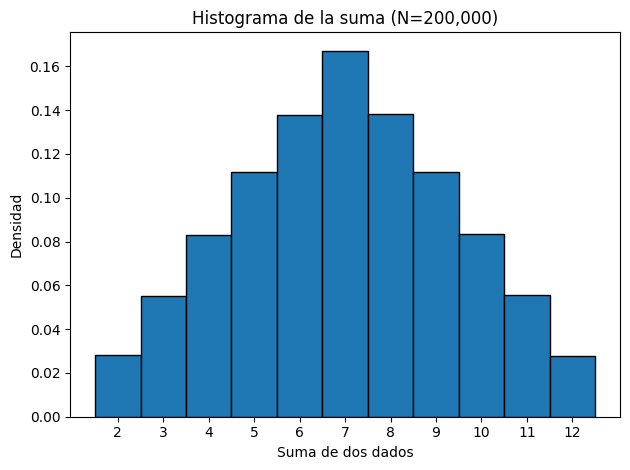

In [1]:
# ============================================================
# Problema 5: Lanzamiento de dos dados
# - Teoría y verificación por simulación
# - Cálculo de IC 95% y visualización opcional
# Requisitos: pip install numpy matplotlib
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -------- Teórico --------
# P(S=7)   = 6/36 = 1/6
# P(S>10)  = 3/36 = 1/12

def simular_dados(N=1000000, seed=2025):
    """
    Simula N lanzamientos de dos dados justos y estima:
      - p_hat_7    = P(S=7) por simulación
      - p_hat_gt10 = P(S>10) por simulación
    Devuelve dict con estimaciones, errores e IC 95% (aprox normal binomial).
    """
    rng = np.random.default_rng(seed)

    # Dos dados ~ Uniforme{1,...,6}, tamaño (N,2)
    tiros = rng.integers(1, 7, size=(N, 2))
    s = tiros.sum(axis=1)

    # Estimaciones empíricas
    p_hat_7 = np.mean(s == 7)
    p_hat_gt10 = np.mean(s > 10)

    # Valores teóricos
    p7 = 1.0 / 6.0
    pgt10 = 1.0 / 12.0

    # Errores
    abs_err_7 = abs(p_hat_7 - p7)
    abs_err_gt10 = abs(p_hat_gt10 - pgt10)
    rel_err_7 = abs_err_7 / p7
    rel_err_gt10 = abs_err_gt10 / pgt10

    # IC 95% (aprox normal de binomial) usando p teórico en la varianza
    z = 1.96
    se7 = np.sqrt(p7 * (1 - p7) / N)
    segt10 = np.sqrt(pgt10 * (1 - pgt10) / N)
    ic7 = (p_hat_7 - z * se7, p_hat_7 + z * se7)
    icgt10 = (p_hat_gt10 - z * segt10, p_hat_gt10 + z * segt10)

    return {
        "N": N,
        "p_hat_7": p_hat_7, "p7_teor": p7, "IC7": ic7,
        "p_hat_gt10": p_hat_gt10, "pgt10_teor": pgt10, "ICgt10": icgt10,
        "abs_err_7": abs_err_7, "rel_err_7": rel_err_7,
        "abs_err_gt10": abs_err_gt10, "rel_err_gt10": rel_err_gt10,
    }

def imprimir_resumen(res):
    """Imprime resultados con formato legible."""
    print(f"N = {res['N']:,}")
    print("\n--- Suma = 7 ---")
    print(f"Teórico     : {res['p7_teor']:.6f}")
    print(f"Simulado    : {res['p_hat_7']:.6f}")
    print(f"Error abs   : {res['abs_err_7']:.6f}   | Error rel: {100*res['rel_err_7']:.3f}%")
    print(f"IC 95% (apox): [{res['IC7'][0]:.6f}, {res['IC7'][1]:.6f}]")

    print("\n--- Suma > 10 ---")
    print(f"Teórico     : {res['pgt10_teor']:.6f}")
    print(f"Simulado    : {res['p_hat_gt10']:.6f}")
    print(f"Error abs   : {res['abs_err_gt10']:.6f} | Error rel: {100*res['rel_err_gt10']:.3f}%")
    print(f"IC 95% (apox): [{res['ICgt10'][0]:.6f}, {res['ICgt10'][1]:.6f}]")

def graficar_histograma(N=200000, seed=123):
    """Grafica histograma de la suma de dos dados para ver el perfil triangular."""
    rng = np.random.default_rng(seed)
    s = rng.integers(1, 7, size=(N, 2)).sum(axis=1)
    plt.figure()
    # bins centrados en cada suma 2..12
    edges = np.arange(2, 14) - 0.5
    plt.hist(s, bins=edges, density=True, edgecolor="black")
    plt.xlabel("Suma de dos dados")
    plt.ylabel("Densidad")
    plt.title(f"Histograma de la suma (N={N:,})")
    plt.xticks(range(2, 13))
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Cambia N para ajustar la precisión (SE ~ 1/sqrt(N))
    resultados = simular_dados(N=1000000, seed=2025)
    imprimir_resumen(resultados)

    # Visualización opcional (comenta si no quieres gráficas):
    graficar_histograma(N=200000, seed=123)
